# Diamond Predictions using Various Models

Three models will be evaluated which is Standard Linear Regression, Random Forest Reggressor and K means Regressor.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import  LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
#load in the data
df = pd.read_csv('C:\\Users\\3019\\machinelearning\\Transport Analytics_DS for Python1.csv')

# Exploratory Data Analysis

In [6]:
#Check the head of the data
df.head()

,DELIVERY DEPOT,DELIVERY LOCATION,PURCHSTATUS,PURCHNAME,SalesQty,PURCHQTY,LINEAMOUNT,ITEMID,DELIVERY DATE,DEPARTMENT,MULTIPLIER,PALLETS
0,NaN,NaN,INVOICED,Maritime Transport Ltd,NaN,NaN,NaN,NaN,NaN,15,NaN,NaN
1,NaN,NaN,INVOICED,Lenham Storage Co. Ltd,NaN,NaN,NaN,NaN,NaN,15,NaN,NaN
2,NaN,NaN,INVOICED,Lenham Storage Co. Ltd,NaN,NaN,NaN,NaN,NaN,15,NaN,NaN
3,NaN,NaN,INVOICED,Lenham Storage Co. Ltd,NaN,NaN,NaN,NaN,NaN,15,NaN,NaN
4,NaN,NaN,INVOICED,Maritime Transport Ltd,NaN,NaN,NaN,NaN,NaN,15,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1387 entries, 0 to 1386
Data columns (total 7 columns):
CardNo         1387 non-null int64
Location       1387 non-null object
Designation    1387 non-null object
TACategory     1387 non-null object
dob            1387 non-null object
Age            1387 non-null float64
Basic          1387 non-null float64
dtypes: float64(2), int64(1), object(4)
memory usage: 76.0+ KB


In [5]:
df.describe()

,CardNo,Age,Basic
count,1387.000000,1387.000000,1387.000000
mean,2594.764239,38.591204,0.412199
std,1103.512404,8.650969,0.315323
min,16.000000,20.000000,0.040000
25%,1853.500000,33.000000,0.230000
50%,2827.000000,37.000000,0.340000
75%,3415.000000,43.500000,0.510000
max,5234.000000,74.000000,3.180000


In [6]:
df.columns

Index(['CardNo', 'Location', 'Designation', 'TACategory', 'dob', 'Age',
       'Basic'],
      dtype='object')

In [6]:
df.dtypes

CardNo           int64
Location        object
Designation     object
TACategory      object
dob             object
Age            float64
Basic          float64
dtype: object

In [7]:
df = df.drop('CardNo', axis =1)

In [9]:
df = df.drop('dob', axis =1)

In [10]:
df.head()

,Location,Designation,TACategory,Age,Basic
0,Noida,Business Head,II,63.0,2.57
1,Noida,Head,II,57.0,2.65
2,Noida,Head,II,55.0,2.65
3,Noida,Assistant General Manager,V,67.0,0.83
4,Noida,Head,I,55.0,2.64


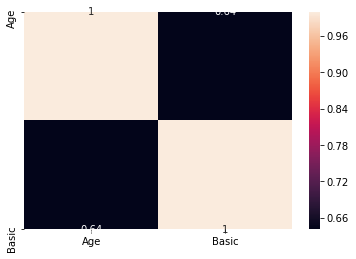

In [11]:
sns.heatmap(df.corr(),annot=True);

# Prepare the data set and work on feature engineering

There is a high amount of correlation between the the diamond dimensions. 
So it might be better to eliminate some of these due to the high amount correlation.

In [12]:
#feature engineering
df.head()

,Location,Designation,TACategory,Age,Basic
0,Noida,Business Head,II,63.0,2.57
1,Noida,Head,II,57.0,2.65
2,Noida,Head,II,55.0,2.65
3,Noida,Assistant General Manager,V,67.0,0.83
4,Noida,Head,I,55.0,2.64


In [15]:
df = df.dropna(axis=0)

In [13]:
df_trans=pd.get_dummies(df)
X = df_trans.drop(['Basic'],axis=1)
y=df_trans['Basic']
features = X.columns

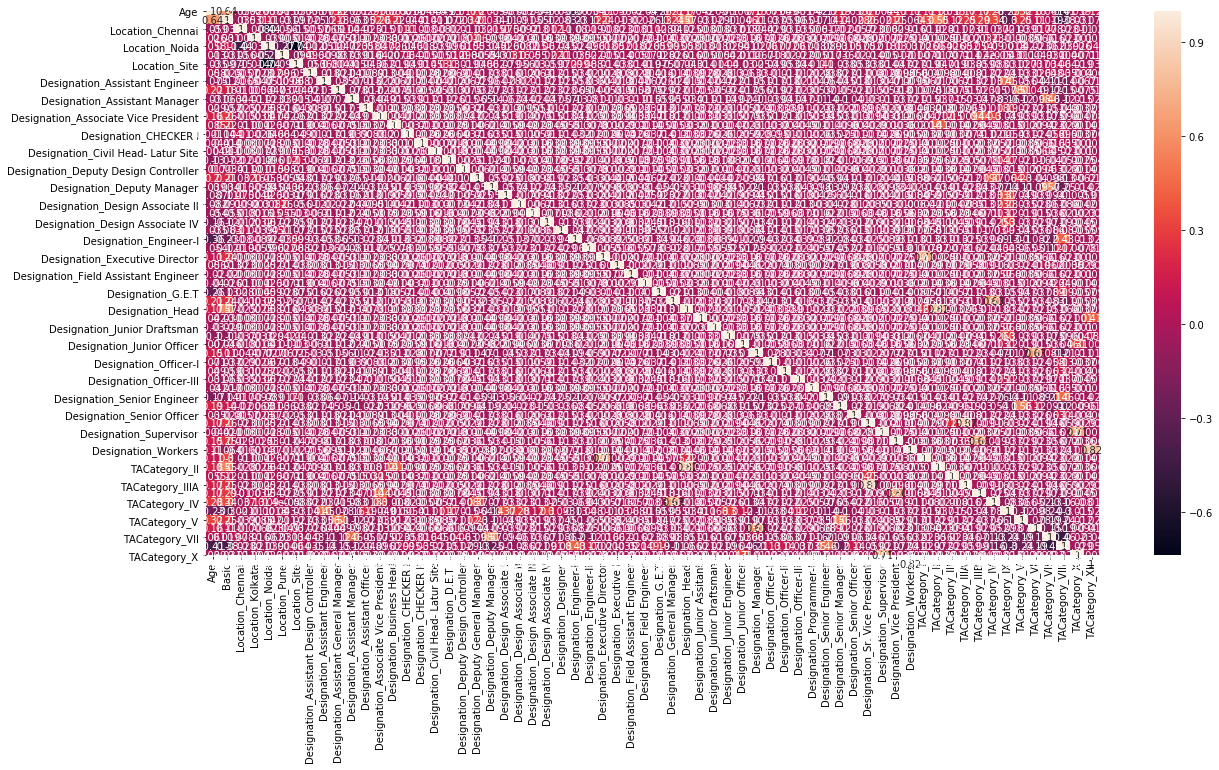

In [14]:
plt.figure(figsize=(20,10))
sns.heatmap(df_trans.corr(),annot=True);

In [15]:
#scale the data
s = StandardScaler()
X = s.fit_transform(X)

In [16]:
X.info();

AttributeError: 'numpy.ndarray' object has no attribute 'info'

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y)

# Prediction and Evaluate the Model Performance

In [18]:
models_eval = pd.DataFrame(index=['Null','KNN','MLR'],columns=['RMSE'])


In [19]:
ypred_null = y_train.mean()

# K-Neighbours Regressor

In [20]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train,y_train)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=7, p=2,
                    weights='uniform')

In [21]:
y_pred = knn.predict(X_test)


# Random Forrest Regression

In [22]:
rf = RandomForestRegressor(n_estimators=10)
rf.fit(X_train,y_train)
y_pred2=y_pred = rf.predict(X_test)


# Linear Regression

In [23]:
lin = LinearRegression()
lin = lin.fit(X_train,y_train)
y_pred3 = lin.predict(X_test)

# Lasso Regression

In [24]:
lasso = Lasso()
lasso.fit(X_train,y_train)
y_pred4 = lasso.predict(X_test)

In [25]:
model_eval=pd.DataFrame(index=['KNN','MLR'],columns=['RMSE'])
model_eval.loc['KNN','RMSE']=np.sqrt(mean_squared_error(y_test,y_pred))
model_eval.loc['RF','RMSE'] = np.sqrt(mean_squared_error(y_test,y_pred2))
model_eval.loc['MLR','RMSE'] = np.sqrt(mean_squared_error(y_test,y_pred3))
model_eval.loc['Lasso','RMSE'] = np.sqrt(mean_squared_error(y_test,y_pred4))
model_eval.loc['NULL','RMSE'] = ypred_null
model_eval

,RMSE
KNN,0.0964794
MLR,1.44062e+11
RF,0.0964794
Lasso,0.266021
NULL,0.41799


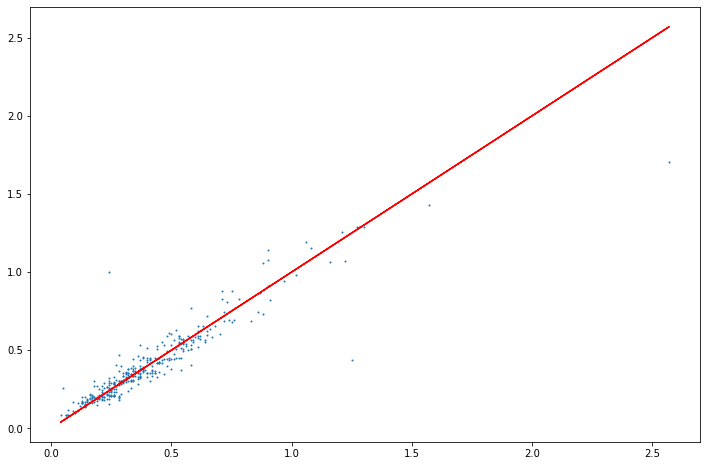

In [26]:
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(y_test,y_pred,s=1)
ax.plot(y_test,y_test,color='red')

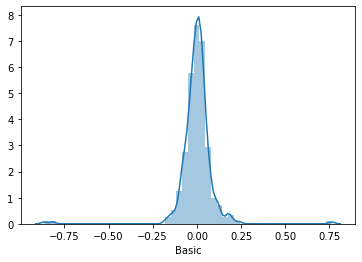

In [27]:
sns.distplot(y_pred-y_test)

In [28]:
lin=LinearRegression()
lin.fit(X_train,y_train)
y_pred2 = lin.predict(X_test)
model_eval.loc['MLR','RMSE']=np.sqrt(mean_squared_error(y_pred2,y_test))

In [29]:
#features importance
from sklearn.ensemble import ExtraTreesRegressor
model =ExtraTreesRegressor()
model.fit(X,y)

C:\Users\3019\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


ExtraTreesRegressor(bootstrap=False, criterion='mse', max_depth=None,
                    max_features='auto', max_leaf_nodes=None,
                    min_impurity_decrease=0.0, min_impurity_split=None,
                    min_samples_leaf=1, min_samples_split=2,
                    min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=None,
                    oob_score=False, random_state=None, verbose=0,
                    warm_start=False)

In [30]:
model.feature_importances_.tolist()

[0.16688055505006436,
 0.00044403023361564483,
 5.141872419127252e-07,
 0.0008950235796042578,
 0.00041235319239393494,
 0.0013048614562427663,
 0.00036480819193021336,
 3.3536341886975435e-05,
 0.0010915390892652001,
 0.00786000259037006,
 6.0763168927681855e-05,
 0.005698836374482241,
 0.032399060211454354,
 0.00011804529529026496,
 7.2809213337312e-06,
 4.35965274139356e-05,
 0.00011995652821492548,
 5.06069874353953e-05,
 0.0008049922455567089,
 0.0012330647739042533,
 4.593280574611299e-05,
 0.00014089233890082065,
 0.0001966454180903258,
 0.0006567516342636701,
 0.0001627257256589429,
 0.0015768488731940657,
 0.0010243212725911238,
 0.021229908517499264,
 0.00022529807704256585,
 3.1012037672852103e-07,
 8.276311413817812e-06,
 0.0013392467862665077,
 0.0015463626558711683,
 0.3239584698522642,
 1.7451541235116176e-05,
 8.337452451806317e-05,
 0.0003306119517771498,
 4.151841637316685e-05,
 0.008433846639704362,
 7.169716203849326e-05,
 0.00014352153691775624,
 0.0002048990611015

In [32]:
df['prediction']=knn.predict(X)

In [33]:
df.head()


,Location,Designation,TACategory,Age,Basic,prediction
0,Noida,Business Head,II,63.0,2.57,0.582857
1,Noida,Head,II,57.0,2.65,2.487143
2,Noida,Head,II,55.0,2.65,2.471429
3,Noida,Assistant General Manager,V,67.0,0.83,0.707143
4,Noida,Head,I,55.0,2.64,2.477143
